# Dead-End Branch Simulation Tutorial

This notebook demonstrates how to set up and simulate a district heating network with a dead-end branch using `pandapipes`. You'll create the network, define dynamic load profiles, run a 24-hour time series, and visualize results.

## Imports and Logger Configuration

In [11]:
import pandapipes as pp
import pandapower as ppw
import pandas as pd
import numpy as np
import tempfile
import logging
import os
from pandapower.timeseries.output_writer import OutputWriter
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)


## Create Network and Junctions
Define a T-shaped network with a main loop and a dead-end branch.

In [12]:
# Create empty network
net = pp.create_empty_network(fluid="water")

# Create junctions with geodata - T-shaped network with dead end
j0 = pp.create_junction(net, pn_bar=1, tfluid_k=293.15, name="j0", geodata=(0, 0))    # Return point
j1 = pp.create_junction(net, pn_bar=1, tfluid_k=293.15, name="j1", geodata=(1, 0))    # Supply point
j2 = pp.create_junction(net, pn_bar=1, tfluid_k=293.15, name="j2", geodata=(2, 0))    # Active consumer
j3 = pp.create_junction(net, pn_bar=1, tfluid_k=293.15, name="j3", geodata=(2, 1))    # Dead end point
j4 = pp.create_junction(net, pn_bar=1, tfluid_k=293.15, name="j4", geodata=(1, 1))    # Return from active branch

## Add Pipes
Connect junctions for main loop and dead-end branch.

In [13]:

# Create pipes - Main loop and dead end branch
pp.create_pipe_from_parameters(net, from_junction=j0, to_junction=j1, length_km=1, diameter_m=0.1, name="Pipe 0-1")
pp.create_pipe_from_parameters(net, from_junction=j1, to_junction=j2, length_km=1, diameter_m=0.1, name="Pipe 1-2")
pp.create_pipe_from_parameters(net, from_junction=j2, to_junction=j4, length_km=1, diameter_m=0.1, name="Pipe 2-4")
pp.create_pipe_from_parameters(net, from_junction=j4, to_junction=j0, length_km=1, diameter_m=0.1, name="Pipe 4-0")
# Dead end branch - smaller diameter
pp.create_pipe_from_parameters(net, from_junction=j2, to_junction=j3, length_km=0.5, diameter_m=0.05, name="Dead End Branch")

np.int64(4)

## Add Pump and Consumers
Add a circulation pump and two heat consumers (main loop and dead end).

In [14]:
# Create circulation pump (80°C supply temperature)
pp.create_circ_pump_const_pressure(net, 
                                 return_junction=j0, 
                                 flow_junction=j1, 
                                 p_flow_bar=5, 
                                 plift_bar=0.7, 
                                 t_flow_k=273.15 + 80)

# Create active heat consumer
pp.create_heat_consumer(
    net,
    from_junction=j1,
    to_junction=j2,
    diameter_m=0.1,
    controlled_mdot_kg_per_s=0.5,  # Normal flow in main branch
    qext_w=50000,  # 50 kW heat extraction
    name="Active Consumer"
)

# Create minimal flow consumer at dead end (to prevent complete stagnation)
pp.create_heat_consumer(
    net,
    from_junction=j2,
    to_junction=j3,
    diameter_m=0.05,
    controlled_mdot_kg_per_s=0.01,  # Very low flow
    qext_w=1000,  # Minimal heat extraction
    name="Dead End Consumer"
)


diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.
diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.


np.int64(1)

## Time Series Setup and Load Profiles

In [15]:
# Time series setup
time_steps = 24
time = pd.date_range('2024-01-01', periods=time_steps, freq='h')

# Create heat demand profiles
active_consumer_profile = pd.Series(
    [50000 + 10000 * np.sin(2 * np.pi * t / time_steps) 
     for t in range(time_steps)], 
    index=time
)

dead_end_profile = pd.Series(
    [1000 + 200 * np.cos(2 * np.pi * t / time_steps) 
     for t in range(time_steps)], 
    index=time
)

class DFData:
    def __init__(self, data):
        self.data = data
    
    def get_time_step_value(self, time_step, profile_name=None, scale_factor=1.0):
        value = self.data.iloc[time_step]
        return value * scale_factor

profiles = {
    "active_consumer": DFData(active_consumer_profile),
    "dead_end": DFData(dead_end_profile)
}

## Apply Time Series Controls

In [16]:

from pandapower.control import ConstControl
from pandapipes.timeseries.run_time_series import run_timeseries

# Set up controls
active_consumer_control = ConstControl(
    net,
    element='heat_consumer',
    variable='qext_w',
    element_index=[0],
    profile_name='active_consumer',
    data_source=profiles['active_consumer']
)

dead_end_control = ConstControl(
    net,
    element='heat_consumer',
    variable='qext_w',
    element_index=[1],
    profile_name='dead_end',
    data_source=profiles['dead_end']
)


## Initialize Output Writer

In [17]:
# Initialize output writer
from pandapipes.timeseries import init_default_outputwriter

output_path = "dead_end_results.xlsx"
ow = init_default_outputwriter(net, time_steps, output_path=output_path)


## Run Simulation

In [18]:
# Run simulation
print("\nRunning time series simulation...")
try:
    pp.timeseries.run_timeseries(net, 
                                time_steps=list(range(time_steps)), 
                                mode="sequential",
                                continue_on_divergence=True)
    print("Simulation completed successfully!")
except Exception as e:
    print(f"Simulation error: {str(e)}")
    print("\nAttempting single timestep simulation...")
    pp.pipeflow(net, mode="sequential")



Running time series simulation...


100%|██████████| 24/24 [00:00<00:00, 41.91it/s]

Simulation completed successfully!


## Collect and Save Results

In [19]:
# Collect results
output_data = {}
for key, value in net.output_writer.iat[0, 0].output.items():
    output_data[key] = value

# Save results
with pd.ExcelWriter(output_path) as writer:
    for key, df in output_data.items():
        df.to_excel(writer, sheet_name=key)

print(f"\nResults saved to: {output_path}")


Results saved to: dead_end_results.xlsx


## Summary Statistics

In [20]:
# Print summary
print("\nSimulation Summary:")
print("\nJunction Temperatures:")
junction_temps = output_data['res_junction.t_k'] - 273.15  # Convert to Celsius
for i, name in enumerate(['j0', 'j1', 'j2', 'j3', 'j4']):
    print(f"{name}: {junction_temps.iloc[:, i].mean():.1f}°C")


Simulation Summary:

Junction Temperatures:
j0: 78.7°C
j1: 80.0°C
j2: 76.6°C
j3: 52.7°C
j4: 76.6°C


## Network Snapshots


Flow Velocities:
Pipe 0-1: -0.781 m/s
Pipe 1-2: 0.402 m/s
Pipe 2-4: 0.466 m/s
Pipe 4-0: 0.466 m/s
Dead End Branch: -0.005 m/s


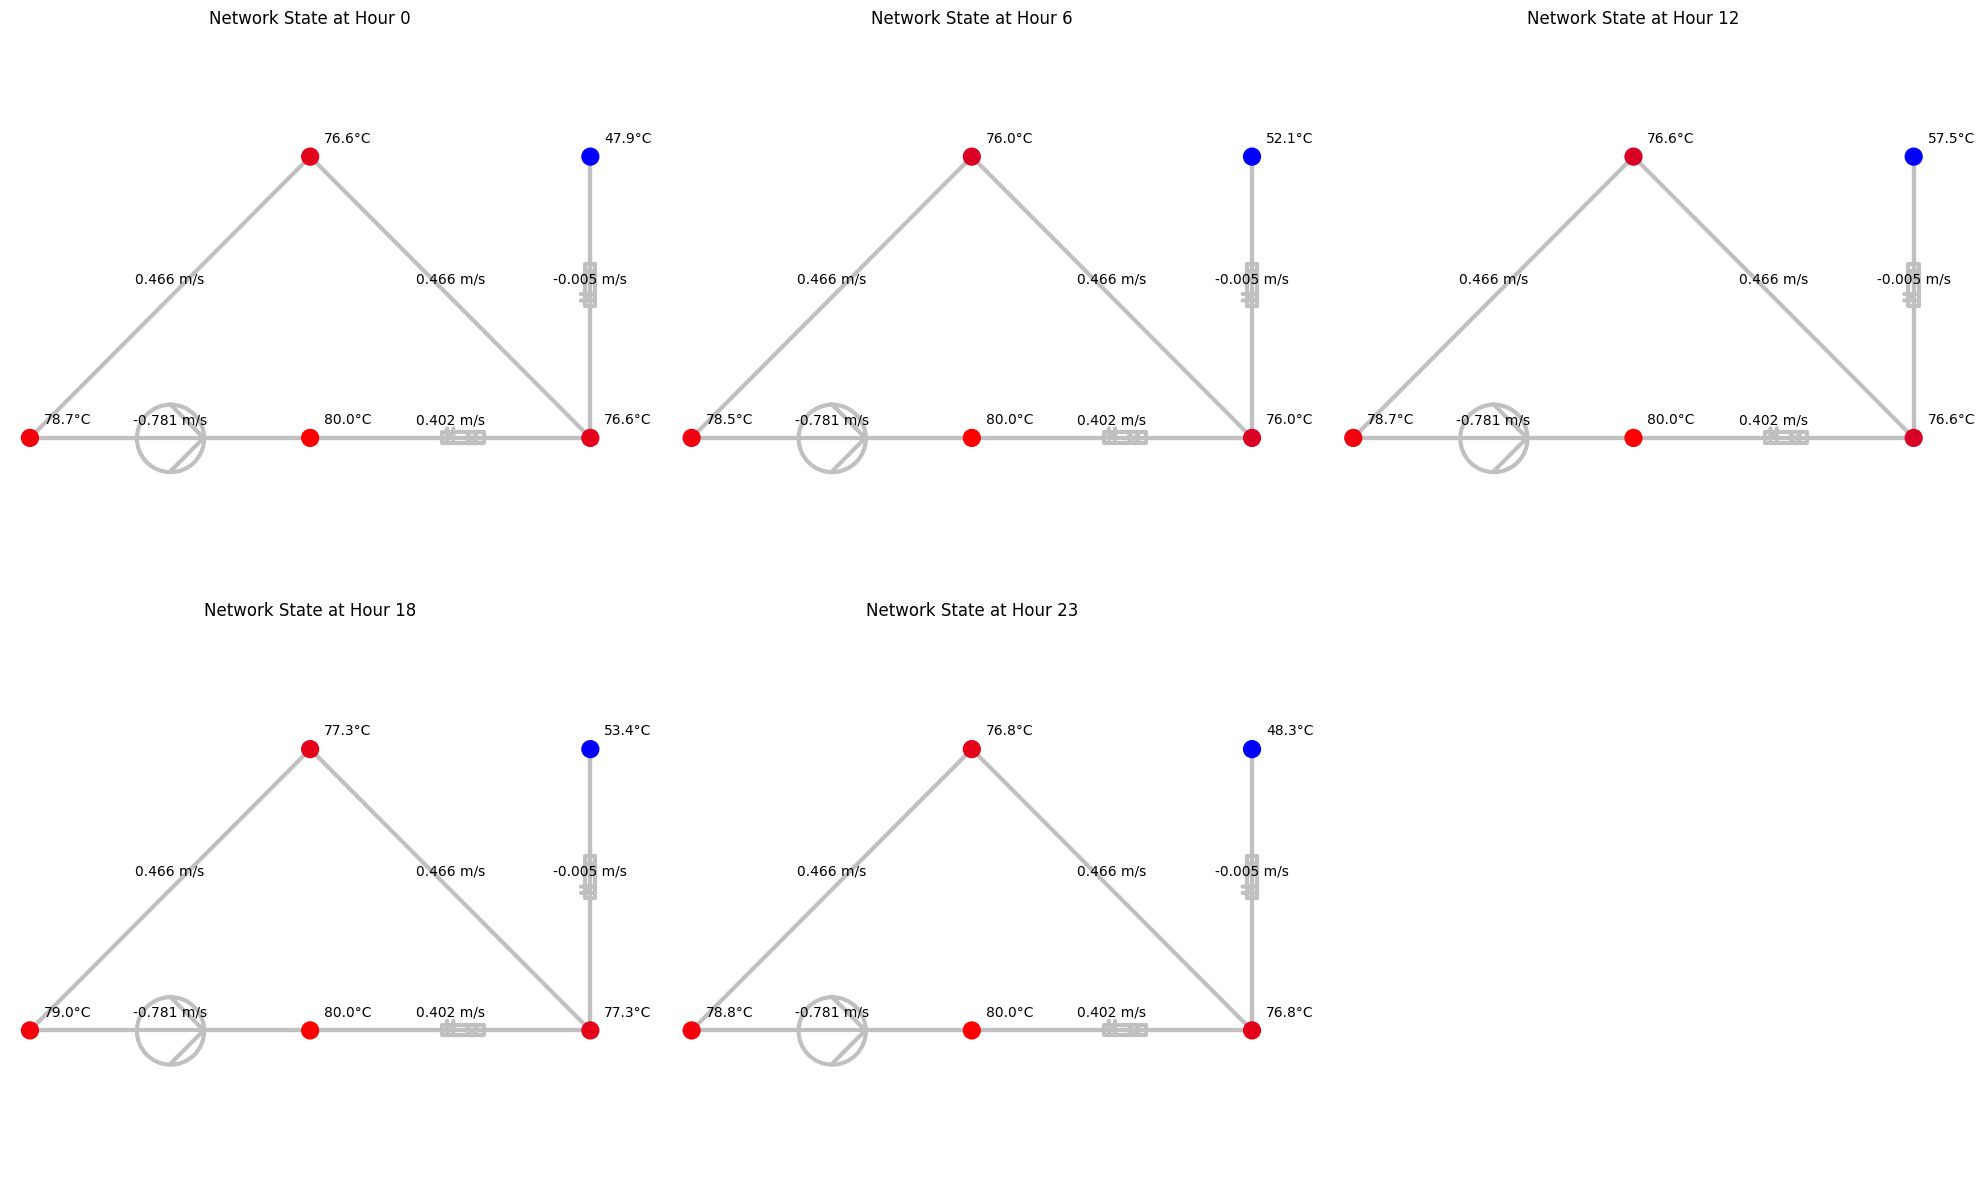

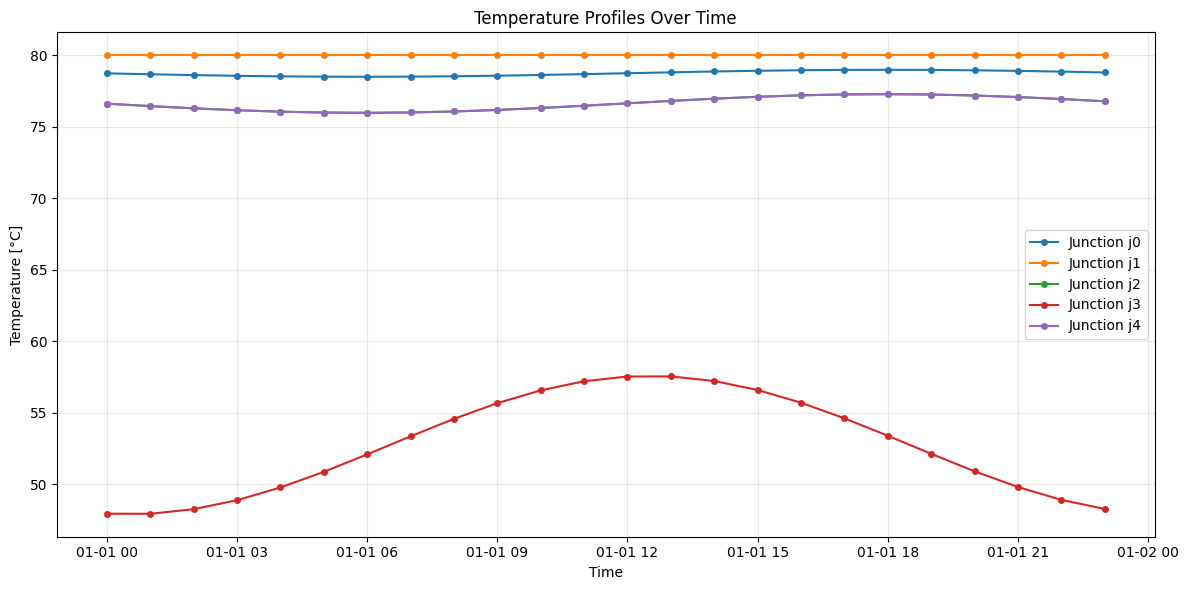

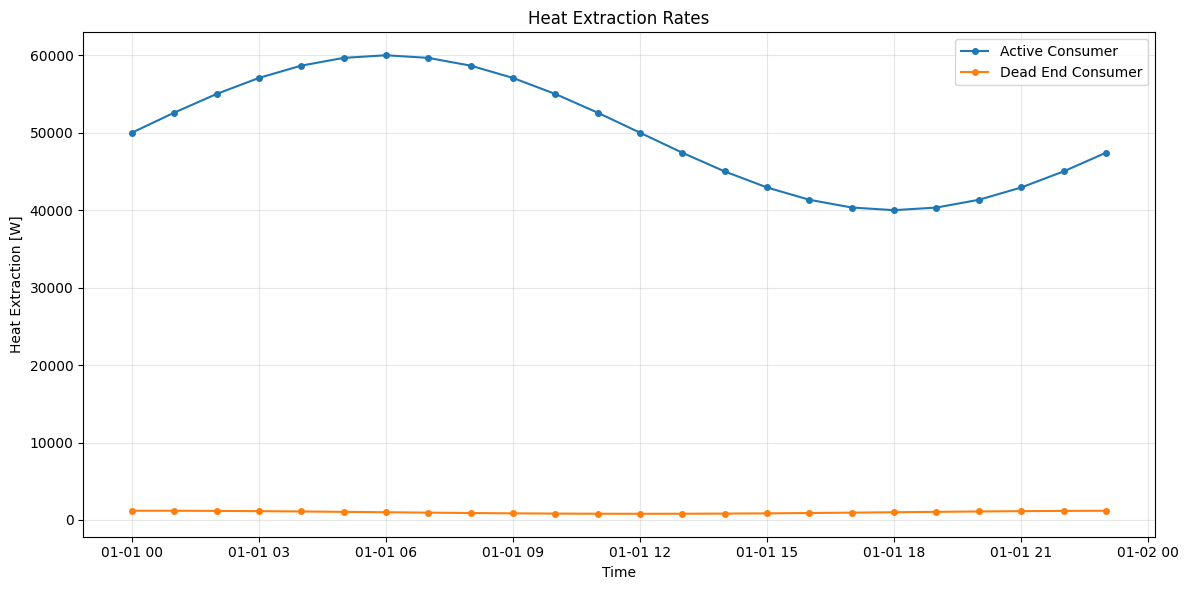

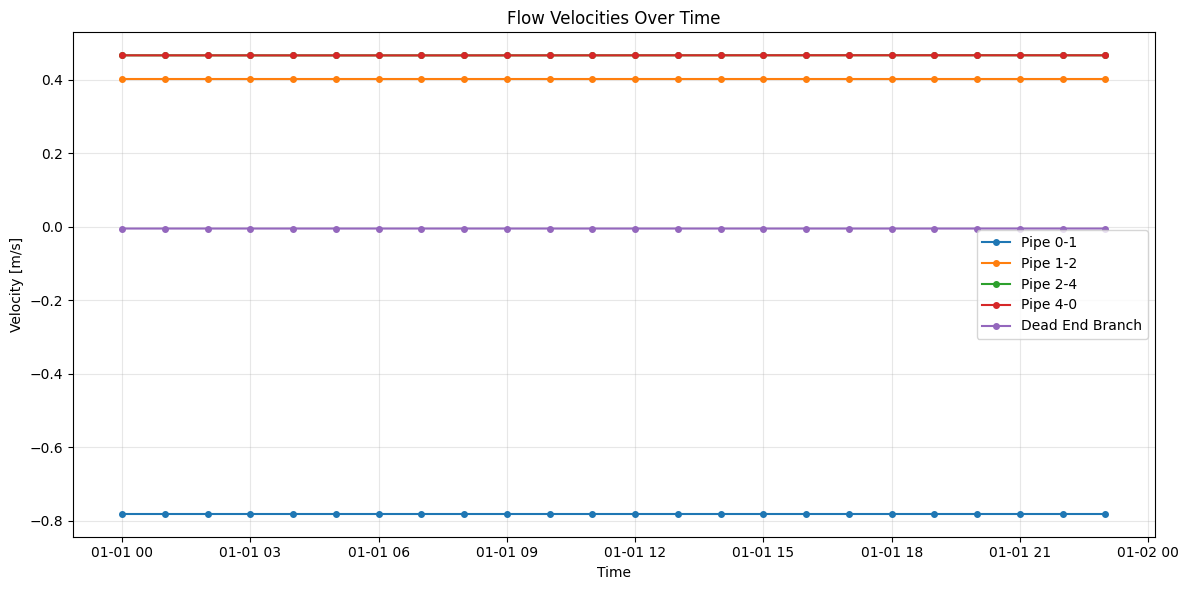

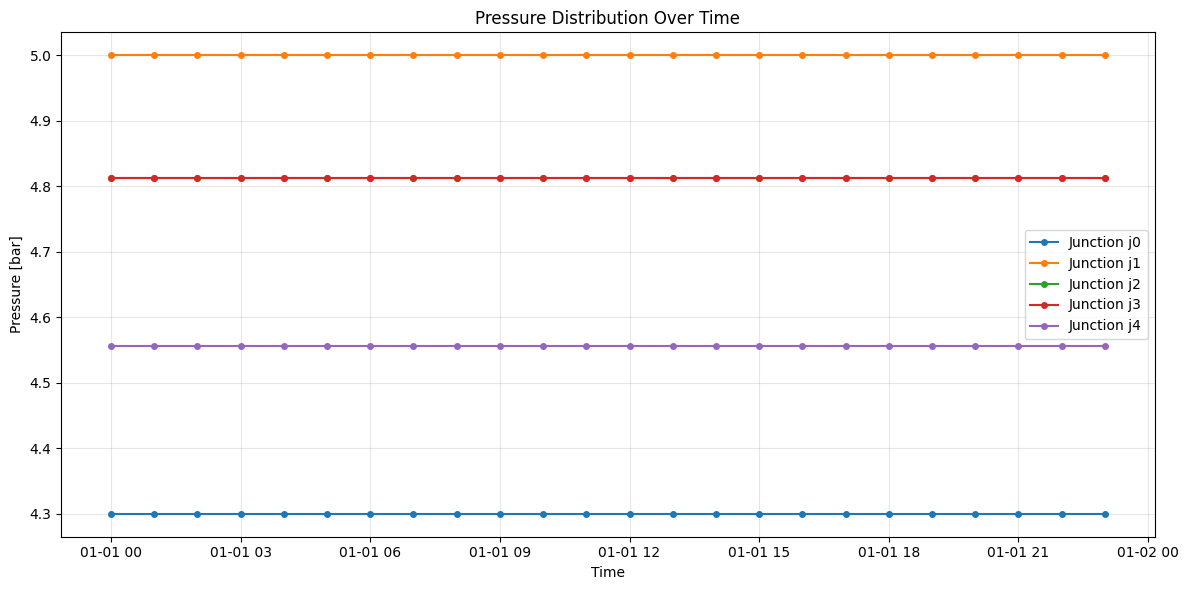

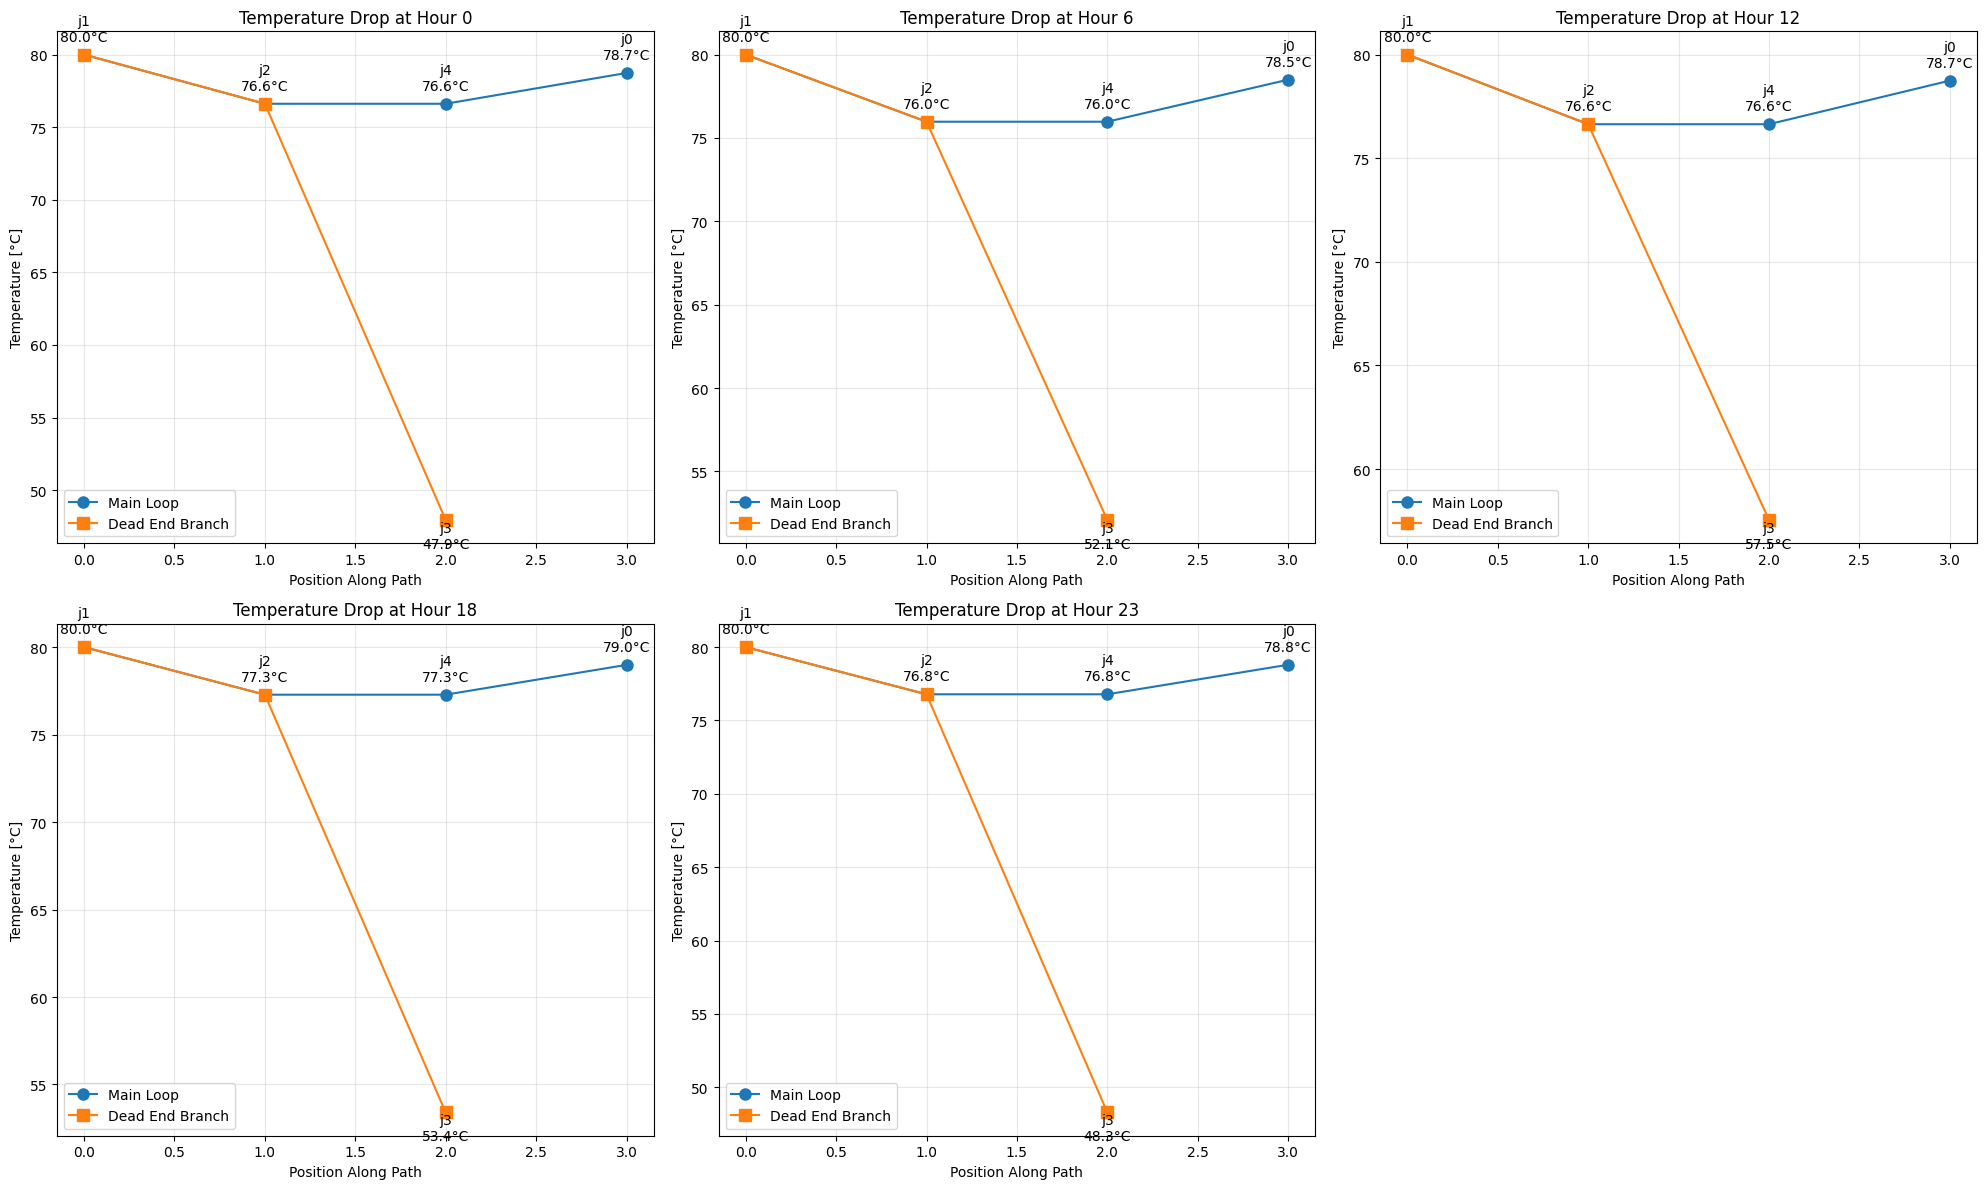


Detailed Analysis:

Temperature Drops:
Main Loop:
Average Supply-Return ΔT: 1.3°C

Dead End Branch:
Average Branch ΔT: 23.9°C

Flow Analysis:
Main Loop vs Dead End Flow Ratio: 77.8

Heat Transfer Analysis:
Main Loop Heat Transfer: 2.6 kW
Dead End Heat Transfer: 1.0 kW
Heat Loss Ratio (Dead End/Main): 37.9%


In [21]:
print("\nFlow Velocities:")
velocities = output_data['res_pipe.v_mean_m_per_s']
for i, name in enumerate(['Pipe 0-1', 'Pipe 1-2', 'Pipe 2-4', 'Pipe 4-0', 'Dead End Branch']):
    print(f"{name}: {velocities.iloc[:, i].mean():.3f} m/s")

# Visualization
def plot_network_timestep(net, timestep, temperatures, velocities, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create color maps
    temp_min = temperatures.min()
    temp_max = temperatures.max()
    
    # Map temperatures to colors (red=hot, blue=cold)
    junction_colors = []
    for temp in temperatures:
        normalized_temp = (temp - temp_min) / (temp_max - temp_min)
        junction_colors.append((normalized_temp, 0, 1-normalized_temp))
    
    # Plot network
    pp.plotting.simple_plot(
        net,
        plot_sinks=True,
        sink_size=1.0,
        junction_size=2.0,
        pipe_width=3.0,
        junction_color=junction_colors,
        ax=ax,
        show_plot=False
    )
    
    # Add temperature labels to junctions
    for i, (x, y) in enumerate(zip(net.junction_geodata.x, net.junction_geodata.y)):
        ax.annotate(f'{temperatures[i]:.1f}°C', 
                   (x, y), 
                   xytext=(10, 10),
                   textcoords='offset points')
    
    # Add velocity labels to pipes
    for i, (from_idx, to_idx) in enumerate(zip(net.pipe.from_junction, net.pipe.to_junction)):
        # Get coordinates for from and to junctions
        from_x = net.junction_geodata.x[from_idx]
        from_y = net.junction_geodata.y[from_idx]
        to_x = net.junction_geodata.x[to_idx]
        to_y = net.junction_geodata.y[to_idx]
        
        # Calculate midpoint
        mid_x = (from_x + to_x) / 2
        mid_y = (from_y + to_y) / 2
        
        # Add velocity label
        ax.annotate(f'{velocities[i]:.3f} m/s',
                   (mid_x, mid_y),
                   xytext=(0, 10),
                   textcoords='offset points',
                   ha='center')
    
    ax.set_title(f'Network State at Hour {timestep}')
    return ax

# Create visualization for multiple timesteps
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Select timesteps to plot
selected_timesteps = [0, 6, 12, 18, 23]

# Get temperature and velocity data
junction_temps = output_data['res_junction.t_k'] - 273.15
pipe_velocities = output_data['res_pipe.v_mean_m_per_s']

# Plot each timestep
for i, timestep in enumerate(selected_timesteps):
    plot_network_timestep(
        net, 
        timestep, 
        junction_temps.iloc[timestep], 
        pipe_velocities.iloc[timestep], 
        ax=axes[i]
    )

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('dead_end_network.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a directory for plots if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

# 1. Temperature profiles over time
plt.figure(figsize=(12, 6))
for i, name in enumerate(['j0', 'j1', 'j2', 'j3', 'j4']):
    plt.plot(time, junction_temps.iloc[:, i], '-o', label=f'Junction {name}', markersize=4)

plt.title('Temperature Profiles Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature [°C]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/temperature_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Heat extraction rates
plt.figure(figsize=(12, 6))
plt.plot(time, active_consumer_profile, '-o', label='Active Consumer', markersize=4)
plt.plot(time, dead_end_profile, '-o', label='Dead End Consumer', markersize=4)
plt.title('Heat Extraction Rates')
plt.xlabel('Time')
plt.ylabel('Heat Extraction [W]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/heat_extraction.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Flow velocities over time
plt.figure(figsize=(12, 6))
for i, name in enumerate(['Pipe 0-1', 'Pipe 1-2', 'Pipe 2-4', 'Pipe 4-0', 'Dead End Branch']):
    plt.plot(time, velocities.iloc[:, i], '-o', label=name, markersize=4)

plt.title('Flow Velocities Over Time')
plt.xlabel('Time')
plt.ylabel('Velocity [m/s]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/flow_velocities.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Pressure distribution
pressures = output_data['res_junction.p_bar']
plt.figure(figsize=(12, 6))
for i, name in enumerate(['j0', 'j1', 'j2', 'j3', 'j4']):
    plt.plot(time, pressures.iloc[:, i], '-o', label=f'Junction {name}', markersize=4)

plt.title('Pressure Distribution Over Time')
plt.xlabel('Time')
plt.ylabel('Pressure [bar]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pressure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Temperature drop along flow path
def plot_temperature_drop(timestep):
    temps = junction_temps.iloc[timestep]
    
    # Main loop path
    main_path = ['j1', 'j2', 'j4', 'j0']
    main_positions = [0, 1, 2, 3]
    main_temps = [temps[list(net.junction.name).index(j)] for j in main_path]
    
    # Dead end path
    dead_path = ['j1', 'j2', 'j3']
    dead_positions = [0, 1, 2]
    dead_temps = [temps[list(net.junction.name).index(j)] for j in dead_path]
    
    plt.plot(main_positions, main_temps, '-o', label='Main Loop', markersize=8)
    plt.plot(dead_positions, dead_temps, '-s', label='Dead End Branch', markersize=8)
    
    # Add labels for each point
    for i, (pos, temp, name) in enumerate(zip(main_positions, main_temps, main_path)):
        plt.annotate(f'{name}\n{temp:.1f}°C', (pos, temp), xytext=(0, 10),
                    textcoords='offset points', ha='center')
    
    for i, (pos, temp, name) in enumerate(zip(dead_positions, dead_temps, dead_path)):
        if name not in main_path:  # Avoid duplicate labels
            plt.annotate(f'{name}\n{temp:.1f}°C', (pos, temp), xytext=(0, -20),
                        textcoords='offset points', ha='center')

# Create subplots for temperature drop at different times
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, timestep in enumerate(selected_timesteps):
    plt.sca(axes[i])
    plot_temperature_drop(timestep)
    plt.title(f'Temperature Drop at Hour {timestep}')
    plt.xlabel('Position Along Path')
    plt.ylabel('Temperature [°C]')
    plt.grid(True, alpha=0.3)
    plt.legend()

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('plots/temperature_drop_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# Print additional analysis
print("\nDetailed Analysis:")
print("\nTemperature Drops:")
print("Main Loop:")
avg_supply = junction_temps.iloc[:, list(net.junction.name).index('j1')].mean()
avg_return = junction_temps.iloc[:, list(net.junction.name).index('j0')].mean()
print(f"Average Supply-Return ΔT: {avg_supply - avg_return:.1f}°C")

print("\nDead End Branch:")
avg_branch_in = junction_temps.iloc[:, list(net.junction.name).index('j2')].mean()
avg_branch_end = junction_temps.iloc[:, list(net.junction.name).index('j3')].mean()
print(f"Average Branch ΔT: {avg_branch_in - avg_branch_end:.1f}°C")

print("\nFlow Analysis:")
print("Main Loop vs Dead End Flow Ratio: {:.1f}".format(
    abs(velocities.iloc[:, 1].mean() / velocities.iloc[:, -1].mean())
))

# Calculate heat loss
cp_water = 4186  # J/kg·K
rho_water = 1000  # kg/m³

def calculate_heat_transfer(mass_flow, t_in, t_out):
    return mass_flow * cp_water * (t_in - t_out)

print("\nHeat Transfer Analysis:")
main_flow = 0.5  # kg/s from controlled_mdot_kg_per_s
dead_flow = 0.01  # kg/s from controlled_mdot_kg_per_s

main_heat = calculate_heat_transfer(main_flow, avg_supply, avg_return)
dead_heat = calculate_heat_transfer(dead_flow, avg_branch_in, avg_branch_end)

print(f"Main Loop Heat Transfer: {main_heat/1000:.1f} kW")
print(f"Dead End Heat Transfer: {dead_heat/1000:.1f} kW")
print(f"Heat Loss Ratio (Dead End/Main): {(dead_heat/main_heat)*100:.1f}%") 